In [1]:
import numpy as np
import pandas as pd
import awkward as ak
import uproot
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gc
import itertools

In [2]:
base_path = ""
which_file = "pairs"
which_chunk = "Chunk0950"
which_number = ["001_007"]
N_SPLITS = 4
file_names = [""]*N_SPLITS*len(which_number)
for num in range (len(which_number)):
    path = base_path + "_".join([which_file, which_chunk, which_number[num]])
    for i in range(N_SPLITS):
        file_names[i+N_SPLITS*num] = ( path + f"_{i}_v2_with999.pkl" )
print(file_names)

['pairs_Chunk0950_001_007_0_v2_with999.pkl', 'pairs_Chunk0950_001_007_1_v2_with999.pkl', 'pairs_Chunk0950_001_007_2_v2_with999.pkl', 'pairs_Chunk0950_001_007_3_v2_with999.pkl']


```python
"""
Paths:
Chunk0950                    [001_007]
Chunk1000                    [001_005, 006_009]
Chunk1010                    [001_005, 006_010]
Chunk1020                    [001_007]
Chunk1030                    [001_005, 006_011]
Chunk1040                    [001_007]
Chunk1050                    [001_005, 006_010]
Chunk1100                    [001_005, 006_009]
Chunk1110                    [001_005]
Chunk1120                    [001_005, 006_011]
Chunk1130                    [001_008]
Chunk1140                    [001_006, 007_011]
Chunk1150                    [001_007]
Chunk1200                    [001_006, 007_011]
Chunk1210                    [001_008]
Chunk1220                    [001_008]
Chunk1300                    [001_006, 003, 007_010]
"""
```

In [3]:
%%bash
cat "Cuts_for_Chunk0950_001_007.txt"

( ( fNsigmaTPCka.abs() < 2 ) &  (              ( (fPt <= 1.4) & (fNsigmaTOFka.abs() <=4) ) |              ( (fPt.between(1.4,2.0)) & (fNsigmaTOFka.abs() <= 2) )             ) |  ( fNsigmaTPCpi.abs() < 2 ) &  (              ( (fPt <= 1.4) & (fNsigmaTOFpi.abs() <=4) ) |              ( (fPt.between(1.4,2.0)) & (fNsigmaTOFpi.abs() <= 2) )            ))

In [4]:
bucket = []
for item in file_names:
    bucket.append( pd.read_pickle(item)  )
    
df = pd.concat(bucket, ignore_index=True)
 # Debug
print("The starting dataframe has", len(df), "rows and ", len(df.columns), "columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"The starting dataframe occupies {memory:.2f} MB")
df.head()

The starting dataframe has 9491876 rows and  9 columns.
The starting dataframe occupies 790.70 MB


,collision_index,dcaXY_product,inv_mass,anti_mass,pt,pz,decay_length,cos_pointing,particle
0,0,-3.887406e-07,2.024925,2.004279,0.562010,0.217750,0.002837,0.119625,Undecided
1,0,-1.776956e-05,1.630082,1.723747,1.006076,0.707632,0.014159,-0.858506,Anti-D0
2,0,4.085324e-05,2.030803,2.127274,0.937323,-0.326464,0.043936,-0.960780,Anti-D0
3,1,-1.104787e-07,1.760064,1.715242,0.871433,0.458262,0.002074,-0.685242,Anti-D0
4,2,3.436724e-05,1.549974,1.626505,0.808844,0.310051,0.013418,-0.396651,Undecided


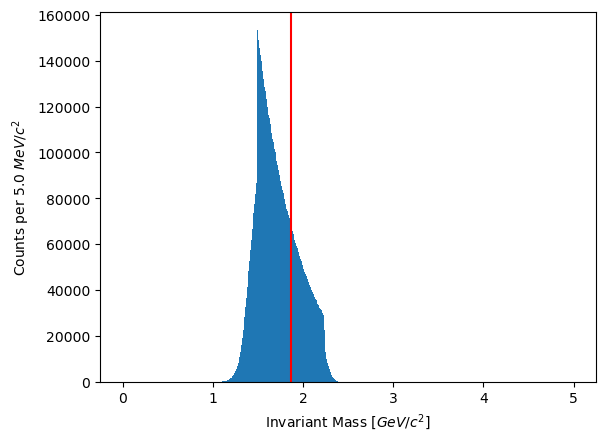

In [5]:
# Particle masses in GeV
m_K = 0.493677
m_pi = 0.139570
m_d0 = 1.86484

# Variables for Plot
MIN_MASS = 0
MAX_MASS = 5
N_BINS = int(1e+03)

masses = np.concatenate([df[df["particle"]=="D0"]["inv_mass"], df[df["particle"]=="Anti-D0"]["anti_mass"],
                         df[df["particle"]=="Undecided"]["inv_mass"], df[df["particle"]=="Undecided"]["anti_mass"]])

# Dummy plot: this takes the same collision index multiple times, with no filtering.
plt.hist(masses, range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000)} $MeV/c^2$")
plt.show()

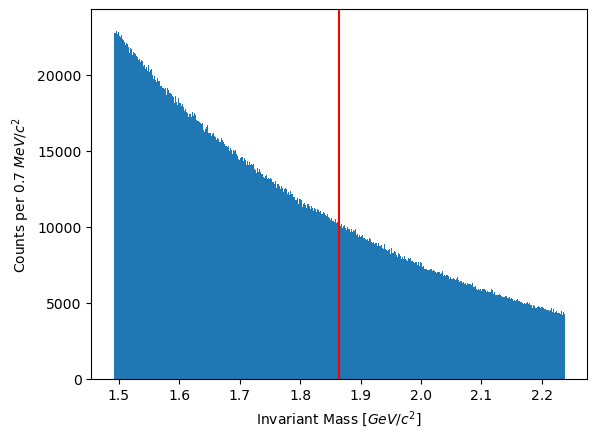

In [6]:
MIN_MASS, MAX_MASS = 0.8*m_d0, 1.2*m_d0
plt.hist(masses, range=(MIN_MASS,MAX_MASS), bins=N_BINS)
plt.axvline(x=m_d0, color="red")
plt.xlabel("Invariant Mass $[GeV/c^2]$")
plt.ylabel(f"Counts per {((MAX_MASS-MIN_MASS)/N_BINS *1000):.1f} $MeV/c^2$")
plt.show()

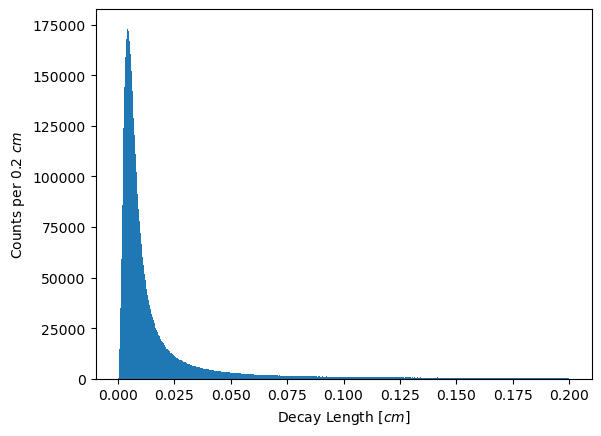

In [7]:
MIN_L, MAX_L = 0, 0.2
plt.hist(df["decay_length"], range=(MIN_L, MAX_L), bins=N_BINS)
plt.xlabel("Decay Length $[cm]$")
plt.ylabel(f"Counts per {((MAX_L-MIN_L)/N_BINS *1000):.1f} $cm$")
plt.show()

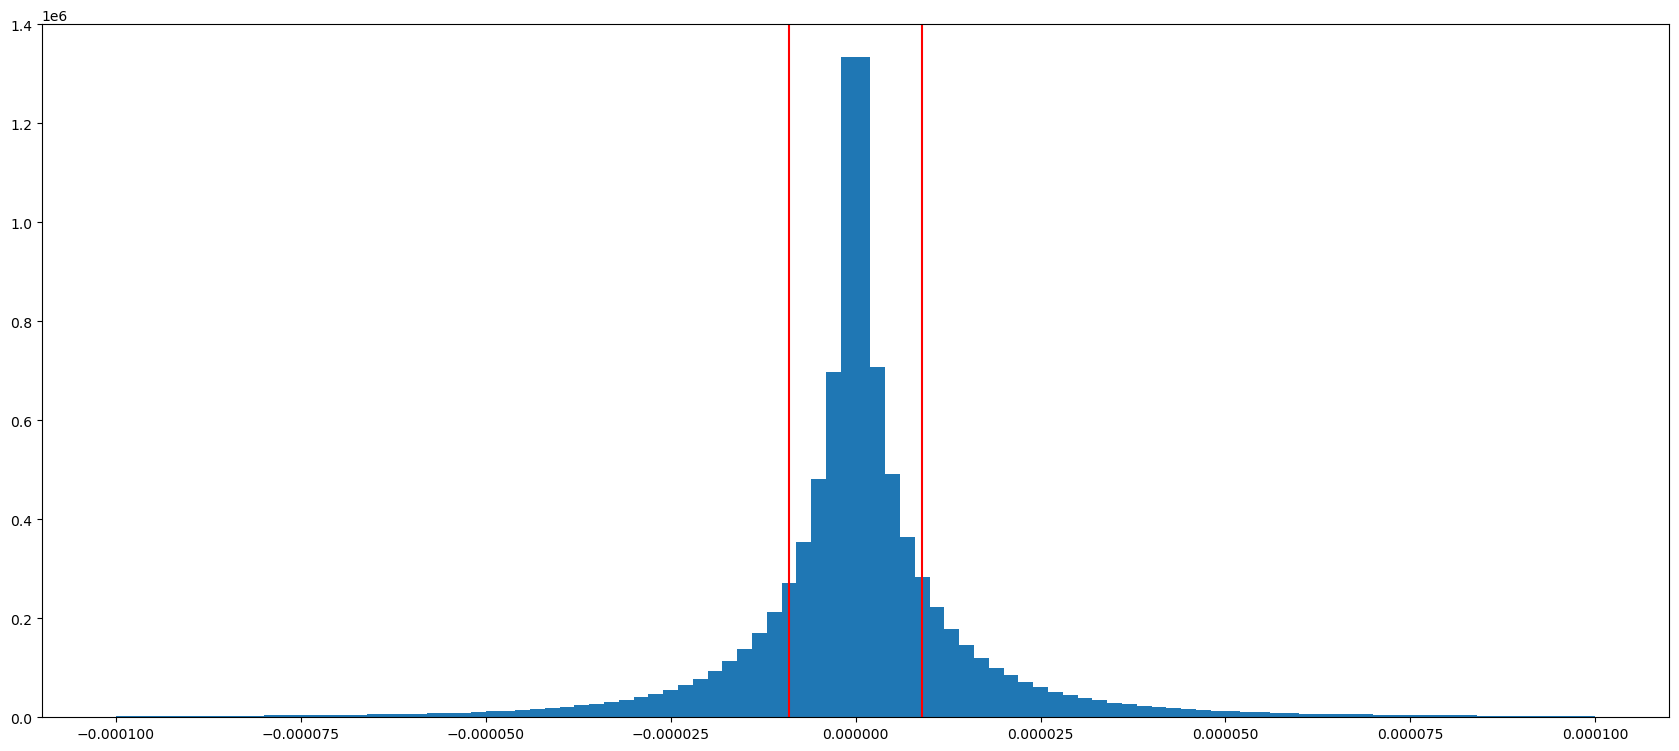

In [8]:
fig, ax = plt.subplots(figsize=(21,9))
plt.hist(df["dcaXY_product"], range=(-1e-04,1e-04), bins=100)
plt.axvline(x=(3e-03)**2, color="red")
plt.axvline(x=-(3e-03)**2, color="red")
plt.show()

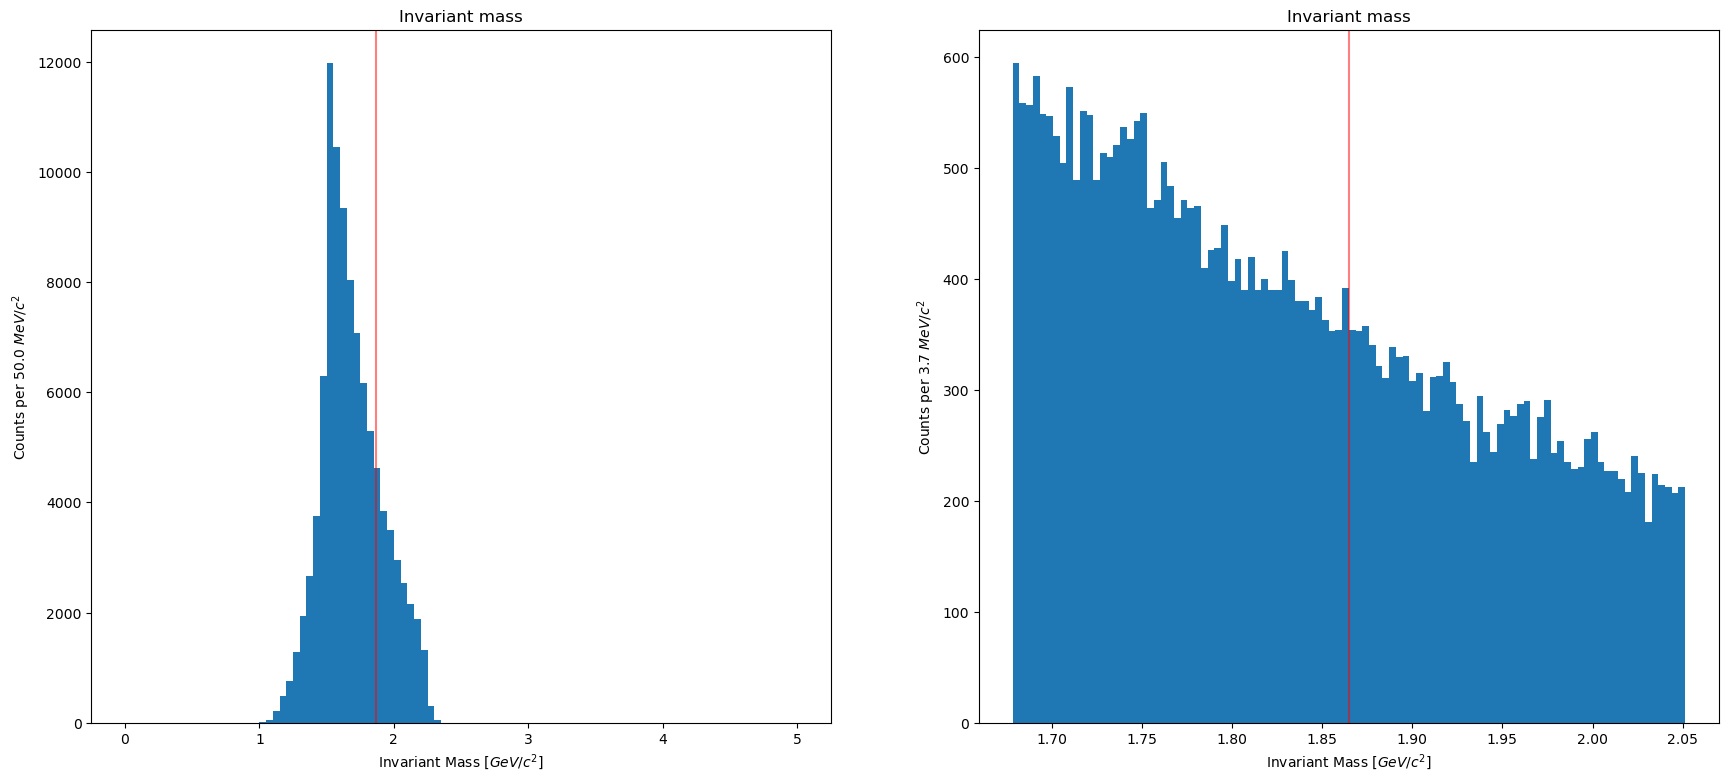

In [13]:
# Now with some filtering
COS_CUT = 0.90
PT_MIN, PT_MAX = 2, 8                                  # +infinity is np.inf
MASS_MIN, MASS_MAX = 0, 5
DCA_CUT = 3e-03
N_BINS = 100

mask = (df["cos_pointing"] > 0.96) & (df["dcaXY_product"]< +3e-06) & ( df["pt"].between(2,8) )
filtered_df = df[mask]

filtered_masses = np.concatenate([filtered_df[filtered_df["particle"]=="D0"]["inv_mass"],
                                  filtered_df[filtered_df["particle"]=="Anti-D0"]["anti_mass"],
                                  filtered_df[filtered_df["particle"]=="Undecided"]["inv_mass"],
                                  filtered_df[filtered_df["particle"]=="Undecided"]["anti_mass"]])


fig, ax = plt.subplots(1,2, figsize=(21,9) )
ax[0].hist(filtered_masses,range=(MASS_MIN,MASS_MAX), bins=N_BINS)
ax[0].axvline(x=m_d0, color="red", alpha=0.5)
ax[0].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[0].set_ylabel(f"Counts per {((MASS_MAX-MASS_MIN)/N_BINS *1000):.1f} $MeV/c^2$")
ax[0].set_title(f"Invariant mass")

M_min, M_max = 0.9, 1.1
N_bins = 100
ax[1].hist(filtered_masses,range=(m_d0*M_min,m_d0*M_max), bins=N_bins)
ax[1].axvline(x=m_d0, color="red", alpha=0.5)
ax[1].set_xlabel("Invariant Mass $[GeV/c^2]$")
ax[1].set_ylabel(f"Counts per {(((M_max-M_min)*m_d0)/N_bins *1000):.1f} $MeV/c^2$")
ax[1].set_title(f"Invariant mass")
plt.show()

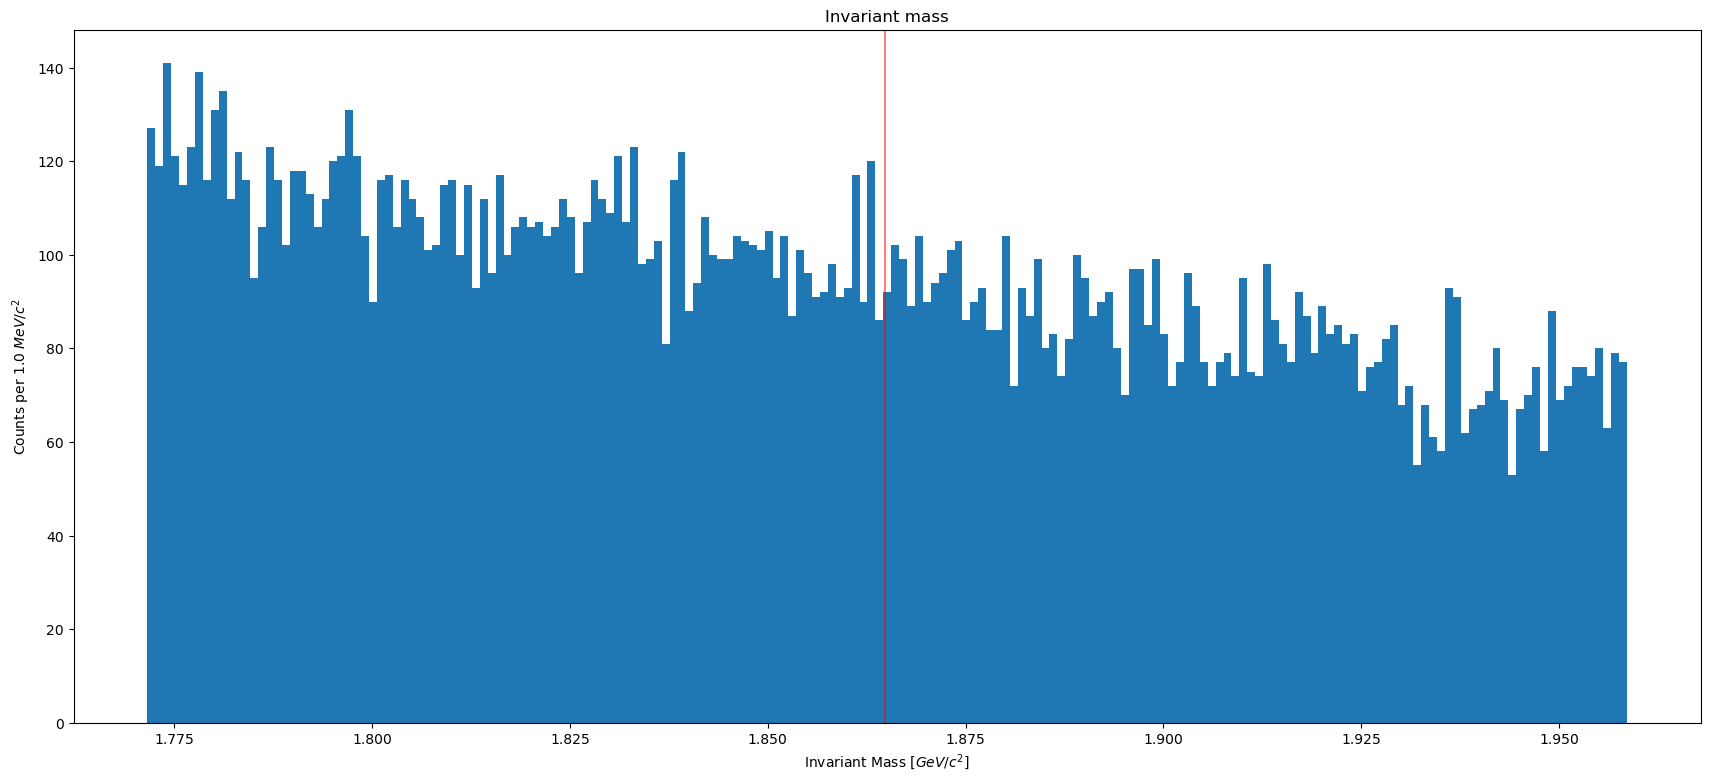

In [19]:
M_min, M_max = 0.95, 1.05
binwdith = 0.001
fig, ax = plt.subplots(figsize=(21,9))
ax.hist(filtered_masses, bins=np.arange(M_min*m_d0, M_max*m_d0+binwdith, binwdith), range=(M_min*m_d0, M_max*m_d0))
ax.axvline(x=m_d0, color="red", alpha=0.5)
ax.set_xlabel("Invariant Mass $[GeV/c^2]$")
ax.set_ylabel(f"Counts per {(binwdith *1000):.1f} $MeV/c^2$")
ax.set_title(f"Invariant mass")
plt.show()